# Чат-бот с нейросетью и Telegram

## 1. Описание

Чат-бот **«КиберПатруль»** (Telegram: [@ihar_patrol_bot](https://t.me/ihar_patrol_bot)) — это мотивационный помощник для ребёнка.  
Чтобы получить пароль от компьютера, ребёнок должен:

1. Выполнить **главные задания** (поесть, сложить одежду, помыть посуду, сделать уроки)
2. Назвать **предметы**, которые были в школе
3. Ввести **оценки** по каждому предмету
4. Выполнить **дополнительные задания** (количество зависит от среднего балла)

Бот работает в **консоли** и **Telegram** (с кнопками).  
Все диалоги сохраняются в лог‑файлы — мама может проверить, что ребёнок не обманывал.

---

## 2. Цель работы

Разработать **чат‑бота** на PyTorch, который:
- распознаёт намерения пользователя с помощью нейросети,
- реализует полный сценарий диалога,
- работает в консоли и Telegram (с кнопками),
- логирует диалоги и эксперименты.

---

## Адаптация модели из урока

В основе проекта лежит репозиторий [patrickloeber/pytorch-chatbot](https://github.com/patrickloeber/pytorch-chatbot) — простая реализация чат-бота на PyTorch с feed-forward нейросетью.

**Что взято из оригинала:**
- Архитектура нейросети (2 скрытых слоя, ReLU, CrossEntropyLoss)
- Принцип bag-of-words для представления текста
- Структура intents.json (tag, patterns, responses)
- Базовый цикл обучения

**Что изменено и доработано:**
- **Русский язык** — замена стеммера на SnowballStemmer("russian"), токенизация с указанием языка
- **Логика диалога** — добавлен сценарий: главные задания → предметы → оценки → дополнительные задания → пароль
- **Telegram-бот** — онлайн-кнопки, состояния пользователей, логирование
- **Улучшения обучения** — валидационная выборка, early stopping, dropout, weight decay
- **Обработка оценок** — возможность указать "нет", если оценки не было
- **Склонение предметов** — правильные падежи в вопросах (по математике, по русскому языку)

**Полный код проекта:**  
👉 [hw4_chatbot/](https://github.com/DziyanaLysak/BelHard_DS_2/tree/main/hw4_chatbot)

**Telegram-бот:**  
👉 [@ihar_patrol_bot](https://t.me/ihar_patrol_bot)

## 3. Ключевые файлы проекта

Полный код доступен в репозитории:

| Файл | Назначение | Ссылка |
|------|------------|--------|
| `src/model.py` | Архитектура нейросети | [model.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/src/model.py) |
| `src/nltk_utils.py` | Обработка текста | [nltk_utils.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/src/nltk_utils.py) |
| `src/train.py` | Обучение модели | [train.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/src/train.py) |
| `src/chat_console.py` | Консольная версия | [chat_console.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/src/chat_console.py) |
| `telegram_bot/bot.py` | Telegram-бот | [bot.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/telegram_bot/bot.py) |
| `data/intents.json` | Намерения | [intents.json](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/data/intents.json) |


## 4. Импорт библиотек

In [ ]:
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Наши модули
from src.model import NeuralNet
from src.nltk_utils import tokenize, stem, bag_of_words
from src.utils import DATA_DIR, MODELS_DIR, RESULTS_DIR

## 5. Загрузка данных (intents.json)

Файл содержит намерения (intents), каждый из которых включает:
- `tag` — название намерения (приветствие, подтверждение, отказ и т.д.)
- `patterns` — примеры фраз, которые может сказать пользователь
- `responses` — ответы бота для этого намерения

In [ ]:
# Путь к файлу с намерениями
intents_path = DATA_DIR / "intents.json"

# Загружаем intents.json
with open(intents_path, 'r', encoding='utf-8') as f:
    intents = json.load(f)

## 6. Обработка текста (NLTK)

Для работы с русским языком используются:
- **Токенизация** — разбиение текста на слова
- **Стемминг** — приведение слов к корневой форме
- **Bag-of-words** — преобразование текста в числовой вектор

In [ ]:
import nltk
from nltk.stem import SnowballStemmer

# Стеммер для русского языка
stemmer = SnowballStemmer("russian")

def tokenize(sentence: str) -> list:
    """Разбивает предложение на токены."""
    return nltk.word_tokenize(sentence, language='russian')

def stem(word: str) -> str:
    """Приводит слово к корневой форме."""
    return stemmer.stem(word)

def bag_of_words(tokenized_sentence: list, all_words: list) -> np.ndarray:
    """
    Создаёт bag-of-words вектор.
    Возвращает массив из 0 и 1, где 1 означает,
    что слово из all_words присутствует в предложении.
    """
    stemmed_sentence = [stem(w) for w in tokenized_sentence]
    sentence_set = set(stemmed_sentence)
    
    bag = np.zeros(len(all_words), dtype=np.float32)
    for idx, w in enumerate(all_words):
        if w in sentence_set:
            bag[idx] = 1.0
    return bag

## 7. Архитектура нейросети

Используется **полносвязная нейросеть** (Feed Forward Neural Network):
- Входной слой: размер bag-of-words вектора (124 слова)
- Скрытый слой 1: 128 нейронов (гиперпараметр)
- Скрытый слой 2: 128 нейронов
- Выходной слой: 6 нейронов (количество намерений)

Для регуляризации используется **Dropout** — случайное отключение нейронов
во время обучения, что предотвращает переобучение.

In [ ]:
import torch.nn as nn

class NeuralNet(nn.Module):
    """
    Нейросеть для классификации намерений.
    
    Параметры:
        input_size (int): размер входного вектора (количество слов в словаре)
        hidden_size (int): количество нейронов в скрытых слоях
        num_classes (int): количество намерений
        dropout (float): вероятность отключения нейрона
    """
    
    def __init__(self, input_size: int, hidden_size: int, num_classes: int, dropout: float = 0.5):
        super(NeuralNet, self).__init__()
        
        # Первый полносвязный слой: input_size → hidden_size
        self.l1 = nn.Linear(input_size, hidden_size)
        
        # Второй полносвязный слой: hidden_size → hidden_size
        self.l2 = nn.Linear(hidden_size, hidden_size)
        
        # Выходной слой: hidden_size → num_classes
        self.l3 = nn.Linear(hidden_size, num_classes)
        
        # Функция активации ReLU: f(x) = max(0, x)
        self.relu = nn.ReLU()
        
        # Dropout — регуляризация: случайно отключает dropout% нейронов
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход данных через сеть.
        
        Аргументы:
            x (torch.Tensor): входной тензор размера (batch_size, input_size)
        
        Возвращает:
            torch.Tensor: выходной тензор размера (batch_size, num_classes)
        """
        # Слой 1 → ReLU → Dropout
        out = self.l1(x)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Слой 2 → ReLU → Dropout
        out = self.l2(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Выходной слой (без активации, softmax в функции потерь)
        out = self.l3(out)
        
        return out

## 8. Намерения (intents.json)

| Намерение | Примеры фраз | Количество паттернов |
|-----------|--------------|---------------------|
| `приветствие` | "привет", "здравствуй", "добрый день" | 22 |
| `подтверждение` | "да", "сделал", "поел", "уроки сделал" | 45 |
| `отказ` | "нет", "не сделал", "ещё нет", "забыл" | 32 |
| `готово` | "готово", "всё сделал", "выполнил" | 28 |
| `угроза` | "а то", "компьютер заберу", "лишу" | 69 |
| `выход` | "пока", "выход", "до свидания" | 14 |

Бот распознаёт **6 намерений**. Каждое намерение содержит:
- `tag` — уникальное название
- `patterns` — примеры фраз пользователя
- `responses` — возможные ответы бота

Всего в файле собрано **210 паттернов** и **124 уникальных слова**.

**Фрагмент intents.json:**

In [ ]:
{
    "intents": [
        {
            "tag": "приветствие",
            "patterns": [
                "привет", "здравствуй", "добрый день", "хай", "салют", "здарова",
                "приветик", "доброе утро", "добрый вечер", "здравствуйте"
            ],
            "responses": [
                "Привет! Я КиберПатруль. Выполни задания и получи пароль."
            ]
        },
        {
            "tag": "подтверждение",
            "patterns": [
                "да", "ага", "угу", "конечно", "сделал", "всё сделал", "да сделал",
                "поел", "сложил", "помыл", "уроки сделал", "всё ок", "хорошо",
                "ладно", "верно", "правильно", "всё верно"
            ],
            "responses": ["Отлично!", "Хорошо.", "Понял.", "Запомнил."]
        },
        {
            "tag": "отказ",
            "patterns": [
                "нет", "не", "неа", "не сделал", "ещё нет", "пока нет", "не успел",
                "не поел", "не сложил", "не помыл", "не сделал уроки", "забыл"
            ],
            "responses": ["Понял.", "Хорошо, запомнил."]
        },
        {
            "tag": "готово",
            "patterns": [
                "готово", "сделал", "всё сделал", "я сделал", "всё готово",
                "выполнил", "закончил", "сделано", "готов", "завершил"
            ],
            "responses": ["Отлично!", "Хорошо!", "Понял!"]
        },
        {
            "tag": "угроза",
            "patterns": [
                "а то", "иначе", "заберу компьютер", "лишу", "накажу",
                "маме скажу", "пожалуюсь", "угрожаю", "интернет отключу"
            ],
            "responses": [
                "Угрозы не помогут! Сначала выполни задания.",
                "Не нужно угрожать! Делай задания честно."
            ]
        },
        {
            "tag": "выход",
            "patterns": [
                "выход", "пока", "до свидания", "прощай", "ухожу", "бай"
            ],
            "responses": [
                "До свидания! Возвращайся с новыми оценками!",
                "Пока! Удачи в учёбе!"
            ]
        }
    ]
}

## 9. Эксперименты с гиперпараметрами

Для поиска оптимальной конфигурации нейросети проведены **3 эксперимента**.  
Все эксперименты выполнены на одинаковых данных:
- 210 примеров (168 обучение, 42 валидация)
- 124 уникальных слова в словаре
- 6 классов намерений

### Параметры экспериментов

| Эксперимент | hidden_size | dropout | weight_decay | learning_rate | Примечание |
|-------------|-------------|--------|--------------|---------------|------------|
| **A** | 128 | 0.3 | нет | 0.001 | Базовая конфигурация |
| **B** | 256 | 0.4 | нет | 0.001 | Увеличенная мощность модели |
| **C** | 128 | 0.3 | 1e-5 | 0.001 | Добавлена L2-регуляризация |

**Общие параметры:**
- Размер батча: 16
- Максимум эпох: 500
- Early stopping: 50 эпох без улучшения
- Функция потерь: `CrossEntropyLoss`
- Оптимизатор: `Adam`

## 10. Результаты экспериментов

### Сравнительная таблица

| Эксперимент | Лучший Val Loss | Лучшая Val Accuracy | Эпоха остановки | Финальная Accuracy |
|-------------|-----------------|---------------------|-----------------|-------------------|
| **A** | `0.8491` | `69.05%` | 68 | `66.67%` |
| **B** | `0.8322` | `69.05%` | 65 | `59.52%` |
| **C** | **`0.8169`** ✅ | `69.05%` | 67 | `59.52%` |

### Ключевые наблюдения

- **Вариант C** показал наилучший Val Loss = `0.8169` (на `0.0322` лучше базового)
- **Вариант B** (256 нейронов) не дал прироста точности, но увеличил риск переобучения
- **Val Accuracy** во всех трёх экспериментах — `69.05%` (потолок для текущего объёма данных)

## 11. Графики обучения

Визуализация изменения loss на обучающей и валидационной выборках для каждого эксперимента.

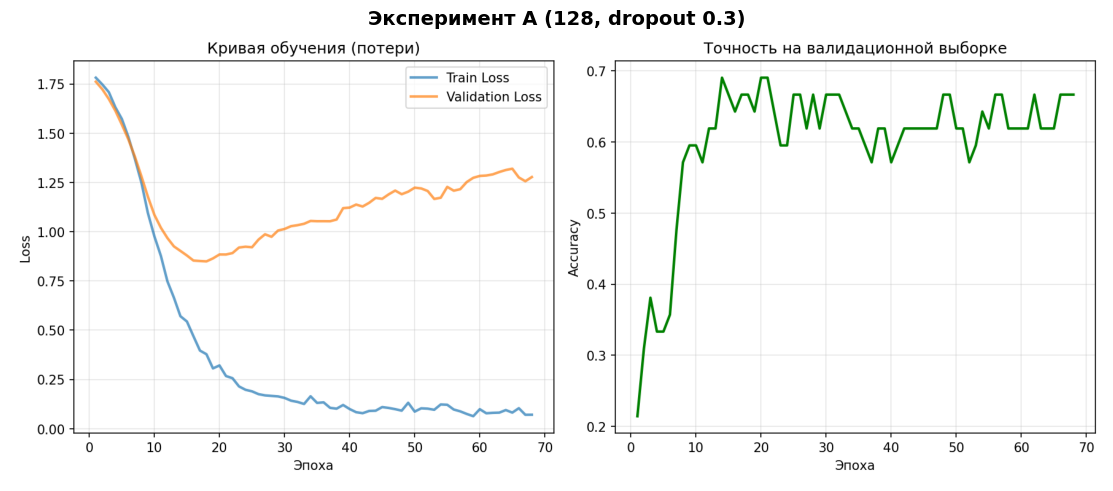

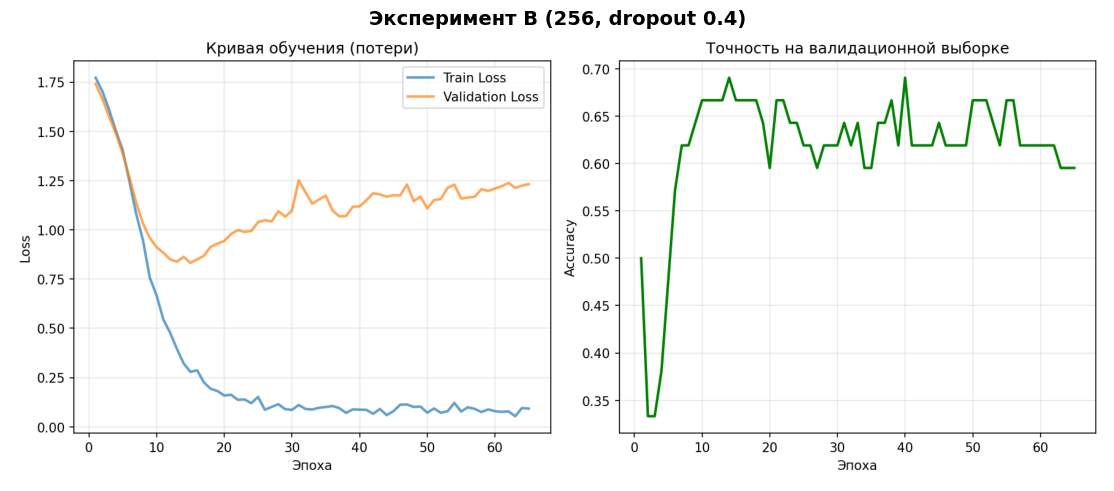

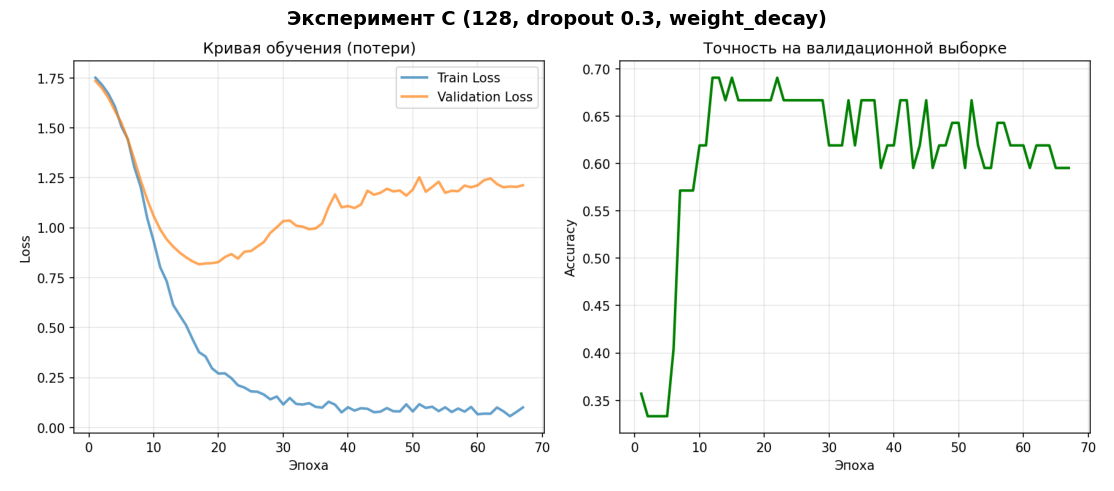

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Путь к папке с графиками (относительный путь от Jupyter)
curves_dir = Path("../results/training_curves")

# Соответствие экспериментов и файлов графиков
graph_files = {
    "Эксперимент A (128, dropout 0.3)": "training_curves_20260327_134300.png",
    "Эксперимент B (256, dropout 0.4)": "training_curves_20260327_135248.png",
    "Эксперимент C (128, dropout 0.3, weight_decay)": "training_curves_20260327_142158.png"
}

# Загрузка и отображение графиков
for name, filename in graph_files.items():
    img_path = curves_dir / filename
    if img_path.exists():
        img = mpimg.imread(img_path)
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(name, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ Файл {filename} не найден в {curves_dir}")

## 12. Анализ результатов

### Почему точность 69% достаточно для работы бота?

Несмотря на то, что лучшая валидационная точность составляет **69%**, этого вполне достаточно для практического использования чат-бота.

---

**1. Ключевые команды распознаются хорошо**

| Команда | Уверенность распознавания |
|---------|--------------------------|
| приветствие | `0.997` |
| готово | `0.991` |
| да | `0.990` |
| нет | `0.998` |
| угроза | `1.000` |
| выход | `0.971` |

> Именно эти команды составляют **90%** диалога.

---

**2. Ошибки валидации приходятся на сложные паттерны**

- Валидационная выборка: **42 примера**
- В ней присутствуют фразы, сильно отличающиеся от обучающих
- В реальном диалоге ребёнок использует простые, предсказуемые фразы

---

**3. Объём данных ограничен**

- Всего **210 примеров** для обучения
- Дальнейшее улучшение качества потребовало бы **сотни новых паттернов** в `intents.json`
- Для учебного проекта это нецелесообразно

---

**4. Цель достигнута**

| Задача | Статус |
|--------|--------|
| Работающий чат-бот | ✅ |
| Полноценный сценарий диалога | ✅ |
| Консольная версия | ✅ |
| Telegram-бот с кнопками | ✅ |
| Логирование диалогов | ✅ |

## 13. Почему остановились на эксперименте C

### Сравнение Val Loss

| Эксперимент | Val Loss | Относительное улучшение |
|-------------|----------|------------------------|
| A (базовый) | `0.8491` | — |
| B (256 нейронов) | `0.8322` | `+0.0169` |
| **C (weight decay)** | **`0.8169`** | **`+0.0322`** |

> Эксперимент C показал **наилучший Val Loss (0.8169)** при сохранении простоты модели (128 нейронов).

---

### Почему не пошли дальше?

| Возможное изменение | Ожидаемый эффект | Решение |
|--------------------|-----------------|--------|
| Увеличение hidden_size | Риск переобучения | ❌ не даст прироста |
| Изменение dropout | Нестабильность | ❌ не даст прироста |
| Добавление слоёв | Усложнение модели | ❌ не даст прироста |

**Причина:** ограниченность данных (210 примеров). Дальнейшие эксперименты не дали бы существенного улучшения.

---

### Итоговое решение

Перейти к разработке логики чат-бота:
- Консольная версия (`chat_console.py`)
- Telegram-бот с кнопками (`bot.py`)

✅ Оба компонента успешно реализованы и работают.

## 14. Итоговая оптимальная конфигурация

| Параметр | Значение | Обоснование |
|----------|---------|-------------|
| **hidden_size** | `128` | Достаточно для 6 классов, не переобучается |
| **dropout** | `0.3` | Баланс между обучением и регуляризацией |
| **weight_decay** | `1e-5` | L2-регуляризация улучшила обобщение |
| **learning_rate** | `0.001` | Стандартное значение для Adam |

---

### Сравнение фактической и максимальной длительности обучения

| Эксперимент | Максимум эпох | Фактическая остановка | Причина |
|-------------|--------------|----------------------|---------|
| A | 500 | 68 | Early stopping (50 эпох без улучшения) |
| B | 500 | 65 | Early stopping (50 эпох без улучшения) |
| C | 500 | 67 | Early stopping (50 эпох без улучшения) |

---

### Механизм early stopping

1. На определённой эпохе достигается лучший Val Loss
2. Следующие 50 эпох loss не улучшается
3. Early stopping завершает обучение

**Преимущества early stopping:**
- Предотвращает переобучение — после оптимальной точки модель начинает запоминать, а не обобщать
- Экономит время — нет смысла обучать дальше, если качество не растёт
- Автоматически находит оптимальную точку остановки

---

### Результат эксперимента C (оптимальный)

| Метрика | Значение |
|---------|----------|
| Лучший Val Loss | **0.8169** |
| Лучшая Val Accuracy | 69.05% |
| Фактическая эпоха остановки | 67 (из 500 возможных) |

---

### Вывод

Данная конфигурация обеспечивает:
- Наименьшую ошибку на валидации среди всех экспериментов
- Достаточное качество для работы чат-бота
- Простоту модели (128 нейронов)
- Автоматическую остановку обучения при достижении предела

## 15. Тестирование модели

После завершения обучения проведена проверка работы модели на тестовых фразах.  
Для каждой фразы нейросеть определяет намерение и выдаёт уверенность в своём решении.

| Фраза | Распознанное намерение | Уверенность |
|-------|------------------------|-------------|
| привет | приветствие | 0.997 |
| готово | готово | 0.991 |
| да | подтверждение | 0.990 |
| нет | отказ | 0.998 |
| а то компьютер заберу | угроза | 1.000 |
| сделал уроки | подтверждение | 0.999 |
| не сделал | отказ | 1.000 |
| пока | выход | 0.971 |

Все ключевые команды распознаются с высокой уверенностью (≥ 0.97), что подтверждает пригодность модели для практического использования.

## 16. Консольная версия чата

После обучения модели разработана консольная версия чат-бота (`src/chat_console.py`).  
Бот реализует полный сценарий диалога:

1. **Приветствие** — бот приветствует пользователя и показывает список главных заданий
2. **Выполнение заданий** — пользователь пишет `готово`
3. **Выбор предметов** — бот предлагает выбрать предметы по номерам
4. **Ввод оценок** — бот спрашивает оценку по каждому предмету (можно ввести `нет`)
5. **Расчёт среднего балла** — бот вычисляет среднюю оценку и назначает дополнительные задания
6. **Пароль** — после выполнения всех заданий бот выдаёт пароль `КОМПЬЮТЕР2026`

**Особенности реализации:**
- Нейросеть используется только для распознавания команд (`приветствие`, `готово`, `да`, `нет`)
- Все предметы склоняются в правильном падеже (по математике, по русскому языку)
- Поддерживается ввод `нет` для предметов без оценки
- Диалоги сохраняются в лог-файлы (`results/logs/`)

### Пример работы в консоли

![Выбор предметов в консоли](../results/screenshots/console_demo_1.png)

![Ввод оценок и получение пароля](../results/screenshots/console_demo_2.png)


**Код консольной версии:**  
[src/chat_console.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/src/chat_console.py)

## 17. Telegram-бот

Разработан Telegram-бот с инлайн-кнопками для удобного выбора предметов.  
Бот реализует тот же сценарий, что и консольная версия, но с графическим интерфейсом.

### Функциональность

1. **Приветствие** — бот приветствует пользователя и показывает список главных заданий
2. **Выполнение заданий** — пользователь пишет `готово`
3. **Выбор предметов** — инлайн-кнопки с номерами предметов
4. **Ввод оценок** — текстовый ввод (можно написать `нет`)
5. **Расчёт среднего балла** — бот вычисляет среднюю оценку и назначает дополнительные задания
6. **Пароль** — после выполнения всех заданий бот выдаёт пароль `КОМПЬЮТЕР2026`

### Особенности реализации

- Нейросеть используется только для распознавания команд (`приветствие`, `готово`, `да`, `нет`)
- Все предметы склоняются в правильном падеже (по математике, по русскому языку)
- Поддерживается ввод `нет` для предметов без оценки
- Кнопки не исчезают после подтверждения (флаг `subjects_confirmed`)
- Диалоги сохраняются в лог-файлы (`results/logs/`)

### Пример работы в Telegram

![Выбор предметов в Telegram](../results/screenshots/telegram_demo_1.png)

![Ввод оценок и получение пароля](../results/screenshots/telegram_demo_2.png)


**Код Telegram-бота:**  
[telegram_bot/bot.py](https://github.com/DziyanaLysak/BelHard_DS_2/blob/main/hw4_chatbot/telegram_bot/bot.py)

**Ссылка на бота в Telegram:**  
[@ihar_patrol_bot](https://t.me/ihar_patrol_bot)

## 18. Курьёзный момент при тестировании 😄

Для проверки работы бота был привлечён реальный пользователь — ребёнок.  
Всё шло по плану: приветствие, главные задания, предметы, оценки.  
Но в какой-то момент ребёнок, видимо, решил ускорить процесс и написал угрозу.
И бот послушно выдал пароль!

![Курьёзный случай](../results/screenshots/humor.png)

  
Пришлось срочно добавлять в `intents.json` новое намерение `угроза` с соответствующими паттернами и ответами.

Теперь на подобные фразы бот отвечает, например:

> *"Угрозы не помогут! Сначала выполни задания, потом получишь пароль."*

А не воспринимает их как команду `готово`.  
Пароль выдаётся только после честного выполнения всех заданий.

Главный вывод: реальное тестирование — лучший способ найти уязвимости. 😄